In [8]:
import torch.nn.functional as F
from skimage.io import imsave
from PIL import Image, ImageOps
import numpy as np 
import argparse
import torch
import cv2
import pdb
import json
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
from typing import Dict, List
from datasets import load_dataset
from itertools import islice
DEVICE='cuda:0'

# Option A: full dataset
ds = load_dataset("bczhou/LOKI", split="train")

In [9]:
def get_mean_stdinv(img):
    """
    Compute the mean and std for input image (make sure it's aligned with training)
    """

    mean=[123.675, 116.28, 103.53]
    std=[58.395, 57.12, 57.375]

    mean_img = np.zeros((img.shape))
    mean_img[:,:,0] = mean[0]
    mean_img[:,:,1] = mean[1]
    mean_img[:,:,2] = mean[2]
    mean_img = np.float32(mean_img)

    std_img = np.zeros((img.shape))
    std_img[:,:,0] = std[0]
    std_img[:,:,1] = std[1]
    std_img[:,:,2] = std[2]
    std_img = np.float64(std_img)

    stdinv_img = 1 / np.float32(std_img)

    return mean_img, stdinv_img

def numpy2tensor(img):
    """
    Convert numpy to tensor
    """
    img = torch.from_numpy(img).transpose(0,2).transpose(1,2).unsqueeze(0).float()
    return img

def prepare_input(img, device):
    """
    Convert numpy image into a normalized tensor (ready to do segmentation)
    """
    mean_img, stdinv_img = get_mean_stdinv(img)
    img_tensor = numpy2tensor(img).to(device)
    mean_img_tensor = numpy2tensor(mean_img).to(device)
    stdinv_img_tensor = numpy2tensor(stdinv_img).to(device)
    img_tensor = img_tensor - mean_img_tensor
    img_tensor = img_tensor * stdinv_img_tensor
    return img_tensor

def load_jsonl(file_path: str) -> List[Dict]:
    """Load JSONL file and return list of samples."""
    samples = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                samples.append(json.loads(line.strip()))
    return samples

In [10]:
model_file = '/home/jovyan/image-artifacts/baselines/PAL4VST/deployment/pal4vst/swin-large_upernet_unified_512x512/end2end.pt'
model = torch.load(model_file, weights_only=False).to(DEVICE)

In [11]:
# open_ended_vqa_viewer.ipynb

# 1. Import required modules
import json
from PIL import Image
from IPython.display import display
import os

# 2. Load the JSON configuration
json_path = "/home/jovyan/image-artifacts/data/loki/open_ended_vqa.json"
base_dir = os.path.dirname(json_path)

with open(json_path, "rb") as f:
    data = json.load(f)

sample_iter = iter(data)

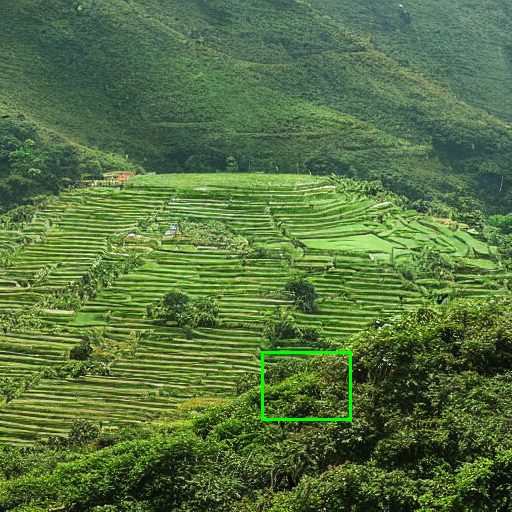

=== Regional Problems ===
Region 1:
  Bounding Box: (x=261.94, y=351.11, w=89.56, h=68.95)
  Description: The boundaries between the terraced fields and the trees are unclear and difficult to distinguish.



In [22]:
import os
import numpy as np
from PIL import Image, ImageDraw
import cv2

# Example sample input
sample = next(sample_iter)
image_path = os.path.join(base_dir, sample["image_path"])

# Load and process image
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
img_tensor = prepare_input(image_rgb, DEVICE).to(DEVICE)
output = model(img_tensor)

# Prepare image and mask
mask_np = (output.cpu().data.numpy()[0][0] * 255.0).astype(np.uint8)
image_np = image_rgb.astype(np.uint8)
image_pil = Image.fromarray(image_np).convert("RGBA")

# Create semi-transparent red overlay from mask
overlay_np = np.zeros((mask_np.shape[0], mask_np.shape[1], 4), dtype=np.uint8)
overlay_np[mask_np > 0] = [255, 0, 0, 128]  # Red with 50% opacity
overlay_pil = Image.fromarray(overlay_np, mode="RGBA")

# Composite mask overlay on image
result = Image.alpha_composite(image_pil, overlay_pil)

# Draw bounding boxes on the result
draw = ImageDraw.Draw(result)
for region_info in sample['problems']['regional']:
    x, y, w, h = region_info['region']
    box = [x, y, x + w, y + h]
    draw.rectangle(box, outline=(0, 255, 0, 255), width=3)  # Green box with full opacity

# Show result
result.show()
# Print regional problem descriptions and bounding boxes
print("=== Regional Problems ===")
for idx, region_info in enumerate(sample['problems']['regional']):
    x, y, w, h = region_info['region']
    desc = region_info['desc']
    print(f"Region {idx + 1}:")
    print(f"  Bounding Box: (x={x:.2f}, y={y:.2f}, w={w:.2f}, h={h:.2f})")
    print(f"  Description: {desc}")
    print()